# Foundations of R Software — Week 11 Practical Notebook
# Chirayu Pritmani
# 23102C0085

## 1. Data Frames — MASS `painters` Dataset


In [ ]:
# Load MASS and inspect the painters data frame
library(MASS)
painters


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


In [ ]:
# Structure and summary
str(painters)
summary(painters)
summary(painters$School)
summary(painters$Composition)


'data.frame':	54 obs. of  5 variables:
 $ Composition: int  10 15 8 12 0 15 8 15 4 17 ...
 $ Drawing    : int  8 16 13 16 15 16 17 16 12 18 ...
 $ Colour     : int  16 4 16 9 8 4 4 7 10 12 ...
 $ Expression : int  3 14 7 8 0 14 8 6 4 18 ...
 $ School     : Factor w/ 8 levels "A","B","C","D",..: 1 1 1 1 1 1 1 1 1 1 ...


  Composition       Drawing          Colour        Expression         School  
 Min.   : 0.00   Min.   : 6.00   Min.   : 0.00   Min.   : 0.000   A      :10  
 1st Qu.: 8.25   1st Qu.:10.00   1st Qu.: 7.25   1st Qu.: 4.000   D      :10  
 Median :12.50   Median :13.50   Median :10.00   Median : 6.000   E      : 7  
 Mean   :11.56   Mean   :12.46   Mean   :10.94   Mean   : 7.667   G      : 7  
 3rd Qu.:15.00   3rd Qu.:15.00   3rd Qu.:16.00   3rd Qu.:11.500   B      : 6  
 Max.   :18.00   Max.   :18.00   Max.   :18.00   Max.   :18.000   C      : 6  
                                                                  (Other): 8  

A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.25   12.50   11.56   15.00   18.00 

### Attach and detach a data frame


In [ ]:
attach(painters)

# Variables can now be referred to directly
summary(School)
summary(Composition)

detach(painters)

# After detach, use painters$ again
summary(painters$School)


A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.25   12.50   11.56   15.00   18.00 

A  B  C  D  E  F  G  H 
10  6  6 10  7  4  7  4

### Subsetting rows


In [ ]:
# Painters belonging to School F
subset(painters, School == "F")


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Durer,8,10,10,8,F
Holbein,9,10,16,13,F
Pourbus,4,15,6,6,F
Van Leyden,8,6,6,4,F


In [ ]:
# Equivalent indexing form
painters[painters[["School"]] == "F", ]


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Durer,8,10,10,8,F
Holbein,9,10,16,13,F
Pourbus,4,15,6,6,F
Van Leyden,8,6,6,4,F


In [ ]:
# Painters with Composition <= 6
subset(painters, Composition <= 6)


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Fr. Penni,0,15,8,0,A
Perugino,4,12,10,4,A
Bassano,6,8,17,0,D
Bellini,4,6,14,0,D
Murillo,6,8,15,4,D
Palma Vecchio,5,6,16,0,D
Caravaggio,6,6,16,0,E
Pourbus,4,15,6,6,F


### Selecting / eliminating columns


In [ ]:
# For School F, remove columns 3 (Colour) and 5 (School)
subset(painters, School == "F", select = c(-3, -5))


,Composition,Drawing,Expression
,<int>,<int>,<int>
Durer,8,10,8
Holbein,9,10,13
Pourbus,4,15,6
Van Leyden,8,6,4


### Split a data frame by a factor


In [ ]:
splitted <- split(painters, painters$School)

# Display all groups
splitted

# Access one group
splitted$A

# Each component is itself a data frame
is.data.frame(splitted$A)


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


,Composition,Drawing,Colour,Expression,School
,<int>,<int>,<int>,<int>,<fct>
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A
Guilio Romano,15,16,4,14,A
Michelangelo,8,17,4,8,A
Perino del Vaga,15,16,7,6,A
Perugino,4,12,10,4,A


[1] TRUE

## 2. Importing Excel Files


In [ ]:
# Install once if needed
if (!requireNamespace("readxl", quietly = TRUE)) {
  install.packages("readxl")
}
library(readxl)


The lecture uses an Excel file such as `spexcel.xlsx`.  
In Colab, upload your Excel file first. The next cells are examples and run after the file is uploaded.


In [ ]:
# Example: read first sheet
# dataspexcel <- read_excel("spexcel.xlsx", sheet = 1)
# dataspexcel


In [ ]:
# Example: extract columns whose names contain spaces
# dataspexcel$`Variable 1`
# dataspexcel$`Variable 2`
# mean(dataspexcel$`Variable 1`)


In [ ]:
# Read second sheet
# dataspexcel2 <- read_excel("spexcel.xlsx", sheet = 2)
# dataspexcel2
# dataspexcel2$`Variable 4`
# dataspexcel2$`Variable 5`
# dataspexcel2$`Variable 6`
# mean(dataspexcel2$`Variable 6`)


In [ ]:
# Limit number of rows read
# dataspexcel4 <- read_excel("spexcel.xlsx", n_max = 3)
# dataspexcel4

# Read a selected Excel range (A1 notation)
# dataspexcel5 <- read_excel("spexcel.xlsx", range = "C1:E7")
# dataspexcel5


## 3. Importing Other File Formats


In [ ]:
# SPSS (.sav) using foreign
if (!requireNamespace("foreign", quietly = TRUE)) {
  install.packages("foreign")
}
library(foreign)

# Example:
# spss_data <- read.spss("datafile.sav")


In [ ]:
# HTML tables using XML
if (!requireNamespace("XML", quietly = TRUE)) {
  install.packages("XML")
}
library(XML)

# Example:
# html_data <- readHTMLTable("filename_or_url")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Other formats available through foreign
# read.octave("file")  # Octave / MATLAB
# read.systat("file")  # SYSTAT
# read.xport("file")   # SAS XPORT
# read.dta("file")     # Stata


## 4. Saving and Writing Data Files


In [ ]:
x <- 1:100
x

# Write vector to a text file
write(x, file = "shalabh.txt")


[1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
 [73]  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
 [91]  91  92  93  94  95  96  97  98  99 100

In [ ]:
# Useful write() options
write(x, file = "data_space.txt", ncolumns = 10, sep = " ")
write(x, file = "data_tab.txt", ncolumns = 10, sep = "\t")


In [ ]:
# Create a small data frame for export examples
student_data <- data.frame(
  Name = c("A", "B", "C", "D"),
  Marks = c(78, 85, 69, 92)
)
student_data

# CSV
write.csv(student_data, file = "student_data.csv", row.names = FALSE)

# General tabular text output
write.table(student_data, file = "student_data.txt",
            sep = "\t", row.names = FALSE, quote = FALSE)


Name,Marks
<chr>,<dbl>
A,78
B,85
C,69
D,92


In [ ]:
# Verify the CSV written above
read.csv("student_data.csv")


Name,Marks
<chr>,<int>
A,78
B,85
C,69
D,92


## 5. Absolute and Relative Frequencies


In [ ]:
# Gender example from the notes:
# 1 = Male, 2 = Female
gender <- c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)
gender

# Absolute frequency
table(gender)

# Relative frequency
table(gender) / length(gender)


[1] 1 2 1 2 1 1 1 2 1 1

gender
1 2 
7 3 

gender
  1   2 
0.7 0.3 

In [ ]:
# Pizza delivery direction example:
# 1 = East, 2 = West, 3 = Central
direction <- c(
  1,1,2,1,2,3,2,2,3,3,3,1,2,3,2,2,3,1,1,3,3,1,2,
  1,3,3,3,2,2,2,2,1,2,2,1,1,1,3,2,2,1,2,3,2,2,1,
  2,3,3,2,1,2,2,3,1,1,2,1,2,3,2,3,2,2,3,1,2,3,3,3,
  2,1,1,1,2,1,1,2,1,2,3,3,1,2,3,3,2,1,2,3,2,1,3,
  2,2,2,2,3,2,2
)

table(direction)
table(direction) / length(direction)


direction
 1  2  3 
28 43 29 

direction
   1    2    3 
0.28 0.43 0.29 

## 6. Partition Values — Quartiles, Deciles and Percentiles


In [ ]:
marks <- c(68, 82, 63, 86, 34, 96, 41, 89, 29,
           51, 75, 77, 56, 59, 42)

marks


[1] 68 82 63 86 34 96 41 89 29 51 75 77 56 59 42

In [ ]:
# Default quartiles
quantile(marks)

# Explicit quartile probabilities
quantile(marks, probs = c(0, 0.25, 0.5, 0.75, 1))

# Custom partitions
quantile(marks, probs = c(0, 0.20, 0.40, 0.60, 0.80, 1))


0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0

0%  25%  50%  75% 100% 
29.0 46.5 63.0 79.5 96.0

0%  20%  40%  60%  80% 100% 
29.0 41.8 57.8 70.8 82.8 96.0

In [ ]:
# Deciles
quantile(marks, probs = seq(0, 1, 0.1))

# Selected percentiles
quantile(marks, probs = c(0.10, 0.25, 0.50, 0.75, 0.90))


0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
29.0 36.8 41.8 52.0 57.8 63.0 70.8 76.6 82.8 87.8 96.0

10%  25%  50%  75%  90% 
36.8 46.5 63.0 79.5 87.8

## 7. Graphics — Scatter Plot


In [ ]:
height <- c(
  166,125,130,142,147,159,159,147,165,156,
  149,164,137,166,135,142,133,136,127,143,
  165,121,142,148,158,146,154,157,124,125,
  158,159,164,143,154,152,141,164,131,152,
  152,161,143,143,139,131,125,145,140,163
)

height


[1] 166 125 130 142 147 159 159 147 165 156 149 164 137 166 135 142 133 136 127
[20] 143 165 121 142 148 158 146 154 157 124 125 158 159 164 143 154 152 141 164
[39] 131 152 152 161 143 143 139 131 125 145 140 163

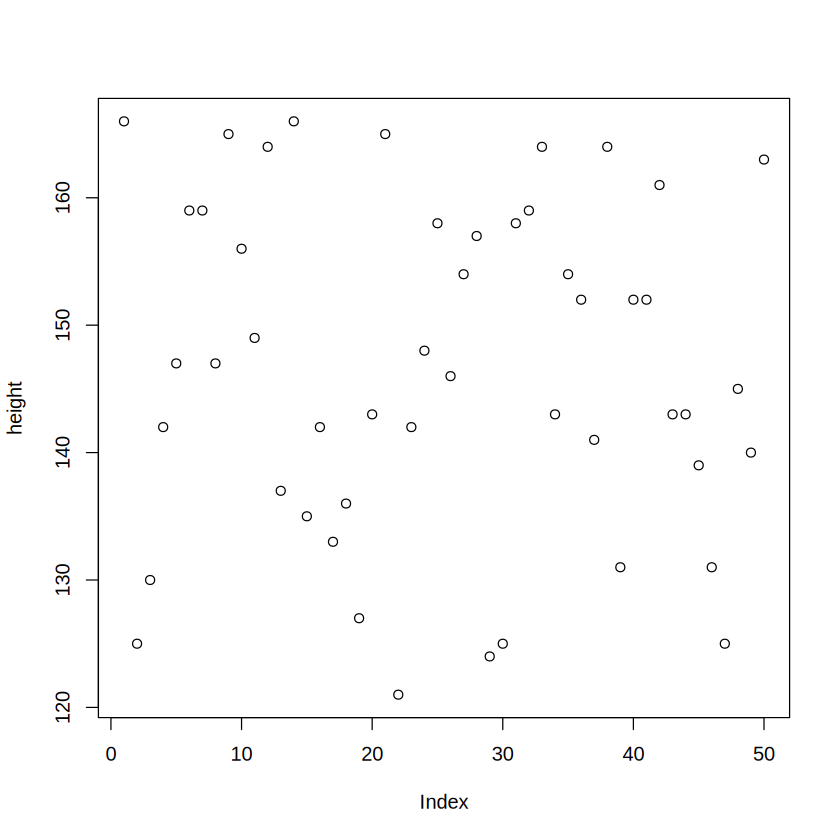

In [ ]:
# Basic one-variable scatter plot
plot(height)


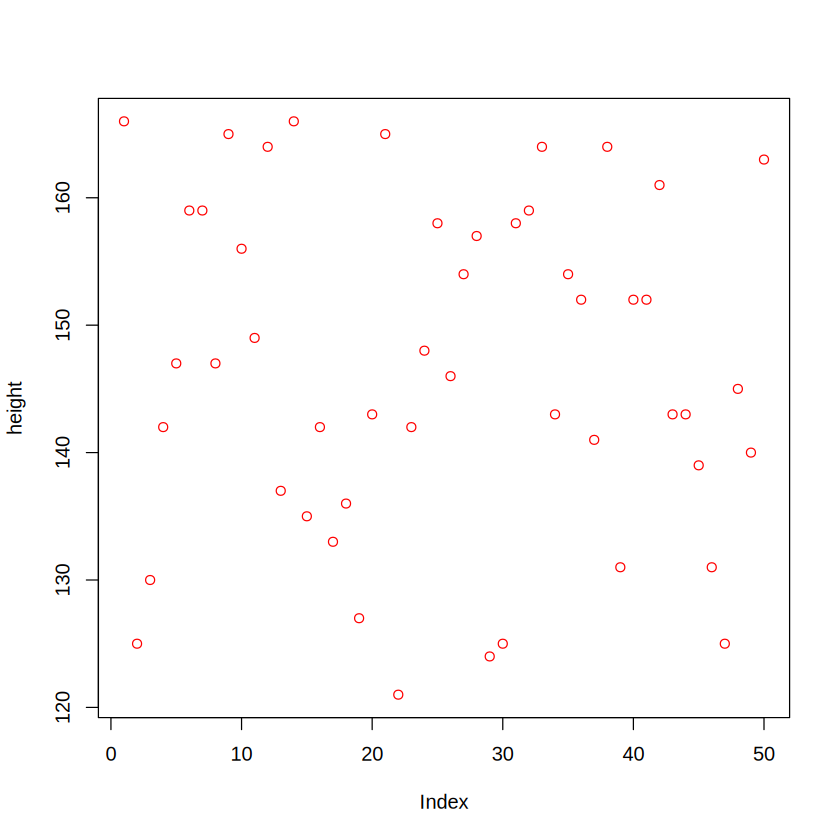

In [ ]:
# Same example with the colour option shown in the lecture
plot(height, col = "red")


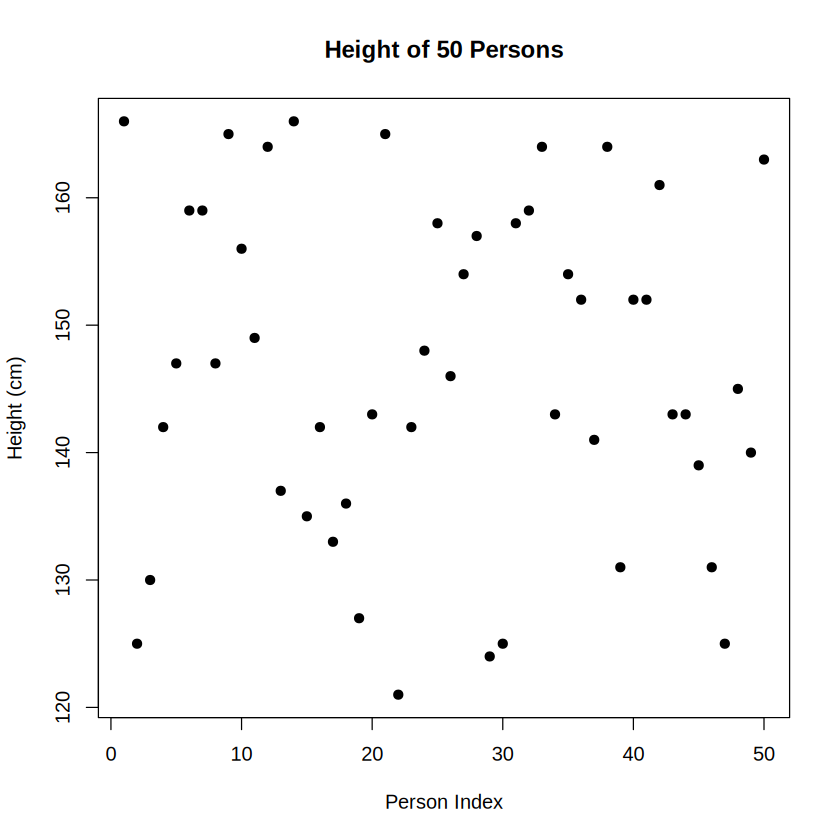

In [ ]:
# A clearer labelled version for practice
plot(height,
     main = "Height of 50 Persons",
     xlab = "Person Index",
     ylab = "Height (cm)",
     pch = 19)


## 8. Bar Plots


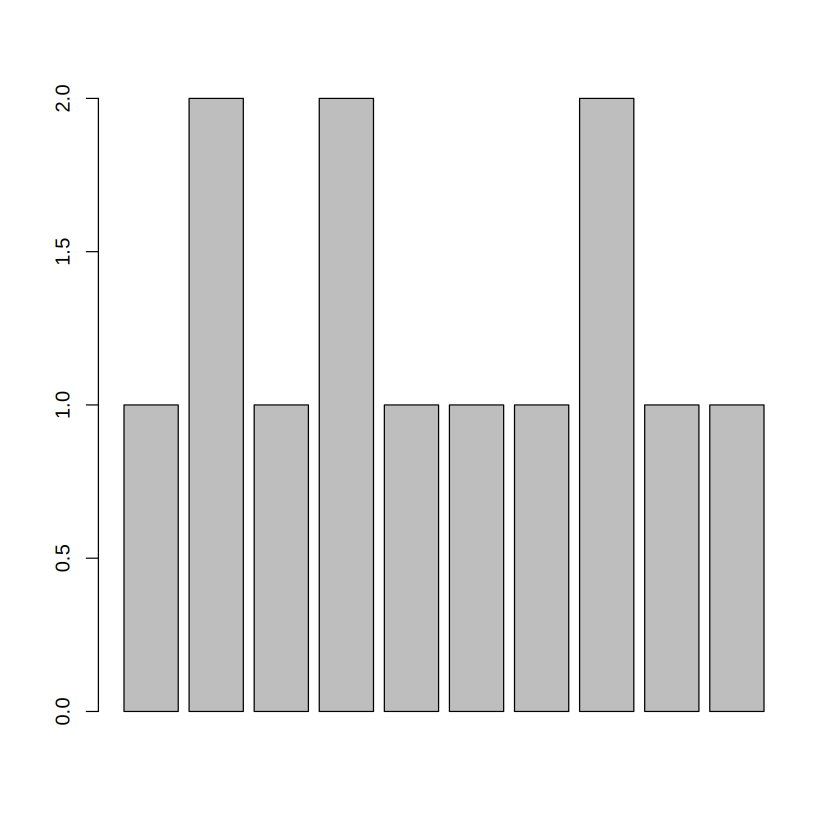

In [ ]:
gender <- c(1, 2, 1, 2, 1, 1, 1, 2, 1, 1)

# This plots the raw values and is NOT the desired frequency bar plot
barplot(gender)


gender
1 2 
7 3 

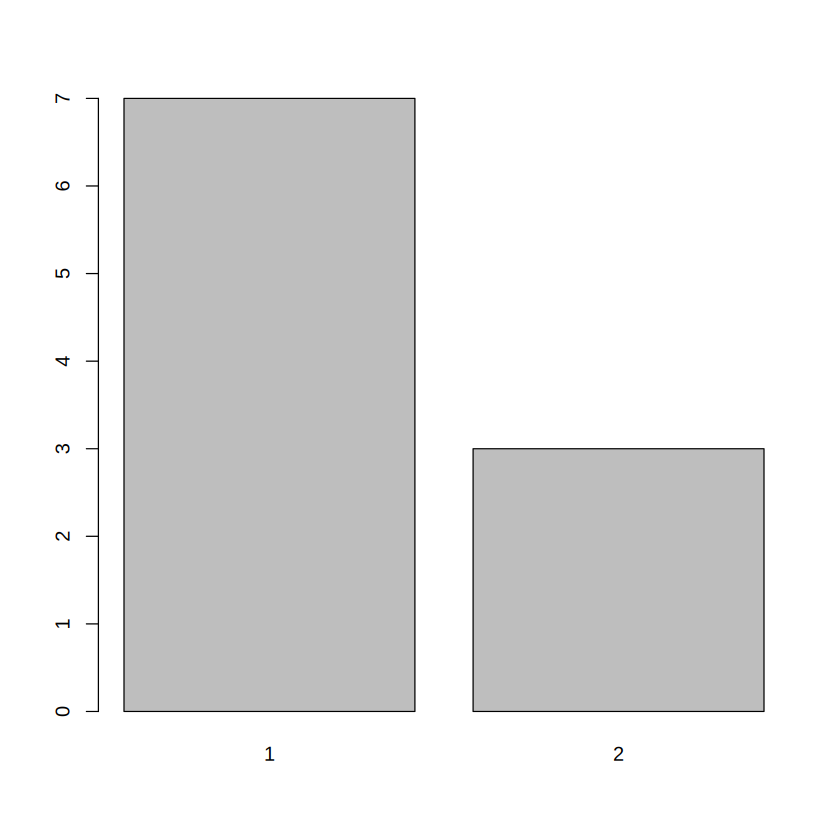

In [ ]:
# Correct: absolute-frequency bar plot
gender_freq <- table(gender)
gender_freq
barplot(gender_freq)


gender
  1   2 
0.7 0.3 

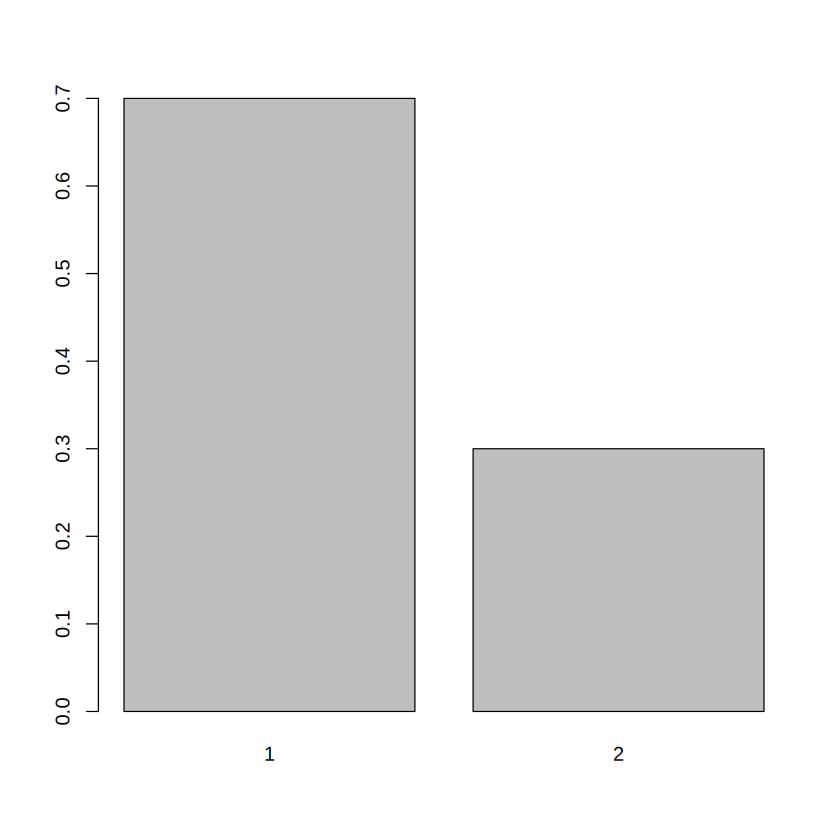

In [ ]:
# Relative-frequency bar plot
gender_rel <- table(gender) / length(gender)
gender_rel
barplot(gender_rel)


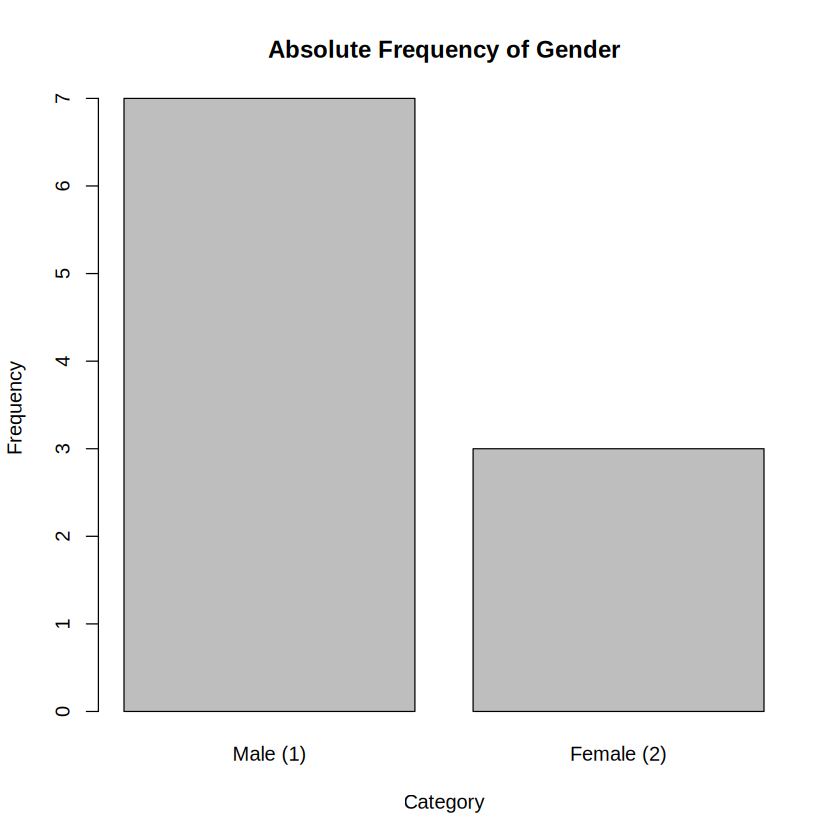

In [ ]:
# Labelled bar plot for easier interpretation
barplot(
  gender_freq,
  names.arg = c("Male (1)", "Female (2)"),
  main = "Absolute Frequency of Gender",
  xlab = "Category",
  ylab = "Frequency"
)


### Additional bar-plot options


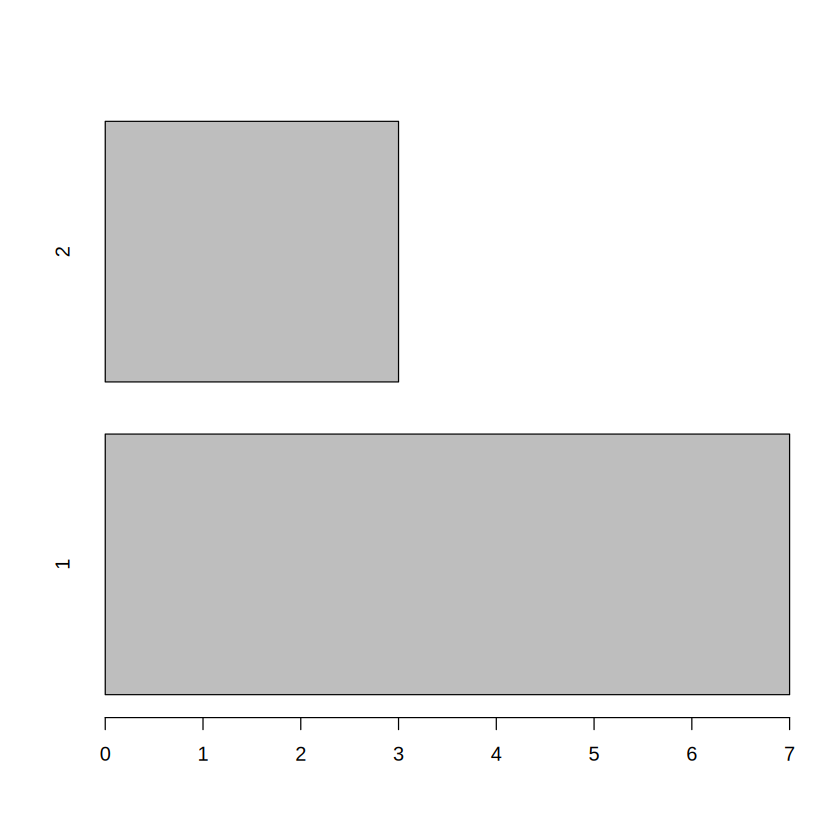

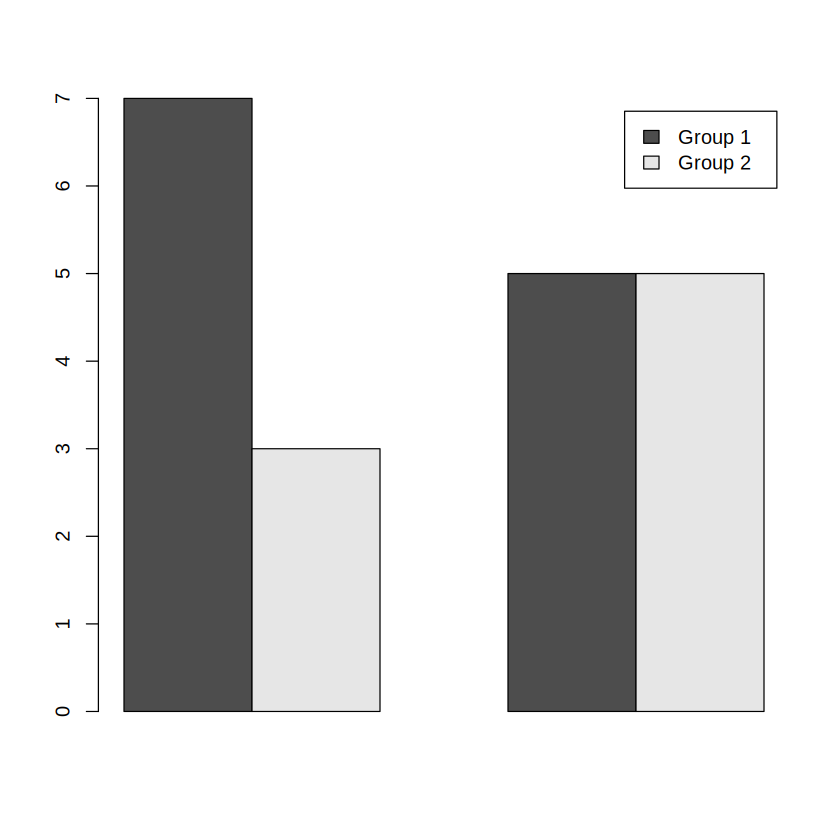

In [ ]:
# Horizontal bar plot
barplot(gender_freq, horiz = TRUE)

# Side-by-side style is useful when plotting a matrix/table
example_matrix <- matrix(c(7,3,5,5), nrow = 2)
barplot(example_matrix, beside = TRUE,
        legend.text = c("Group 1", "Group 2"))
